
1.Имитационная модель (оценка сходимости ниже!)

In [1]:
pip install simpy

=== THEORETICAL ===
P = [0.1111111111111111, 0.2222222222222222, 0.2222222222222222, 0.2222222222222222, 0.2222222222222222]
L = 2.2222222222222223   Lq = 0.6666666666666666   Wq = 0.2857142857142857   W = 0.9523809523809523
P_block = 0.2222222222222222   P_immediate = 0.3333333333333333

=== SIMULATION (mean over replications) ===
P_hat = [0.13858853 0.22381637 0.2123595  0.20532551 0.2199101 ]
L_hat = 2.1441522966519604   Lq_hat = 0.6451457127714256   Wq_hat = 0.2690374913675224   W_hat = 0.9160921980747259
P_block_hat = 0.20559851342208374   P_immediate_hat = 0.4547158204951998


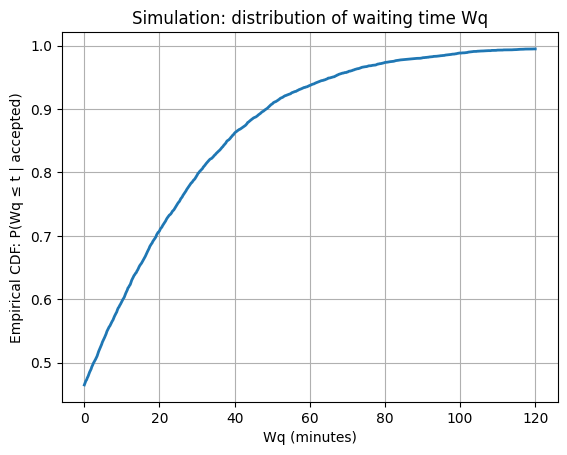

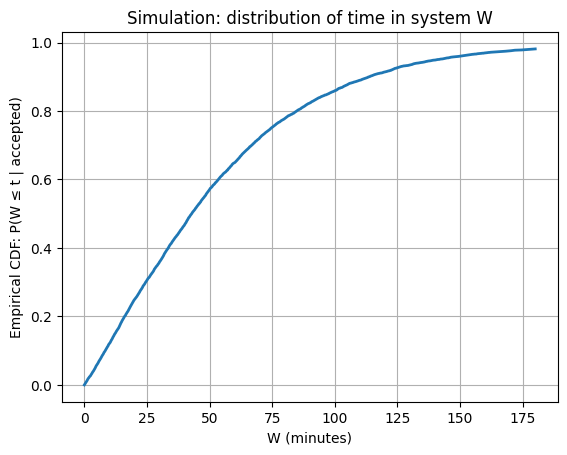

In [4]:

# расписал до душного подробно, чтобы если что самому не забыть что делал)
# M/M/2/4 car wash simulation

#  симулируем автомойку:
# - приходы: Poisson(λ) => межприходы Exp(λ)
# - обслуживание: Exp(μ) на каждом из 2 боксов
# - вместимость системы K=4 (2 обслуживаются + 2 ждут)
# - если N=4, новый клиент получает отказ
#
# Мы собираем:
# - time-average метрики: P_n, L, Lq (через интегралы по времени) - ср. число заявок в системе и очереди
# - customer-average метрики: Wq, W (по принятым заявкам)- ср. время в очереди и системе
# - вероятности отказа и немедленного обслуживания

import math
import numpy as np
import simpy
import matplotlib.pyplot as plt

# -------------------------------------------------------
# BLOCK 1. ПАРАМЕТРЫ ЗАДАЧИ (из условия)


LAMBDA = 3.0         # λ = 3 машины в час (интенсивность прихода)
MU = 1.5             # μ = 1.5 в час (интенсивность обслуживания одного бокса), т.к. E[S]=1/μ=2/3 часа=40 минут
C = 2                # c = 2 бокса (2 "сервера")
K = 4                # K = 4 максимальное число машин в системе (2 моются + 2 ждут)
T_HOURS = 12.0       # автомойка работает 12 часов (горизонт моделирования)


# -------------------------------------------------------
# BLOCK 2. ТЕОРЕТИЧЕСКИЕ (АНАЛИТИЧЕСКИЕ) ЗНАЧЕНИЯ ДЛЯ СРАВНЕНИЯ

# Здесь мы просто фиксируем то, что уже получили аналитически(из ворда),
# чтобы потом сравнить симуляцию с "истиной в модели M/M/2/4".

P0 = 1/9             # P(N=0) в стационарности
P1 = 2/9             # P(N=1)
P2 = 2/9             # P(N=2)
P3 = 2/9             # P(N=3)
P4 = 2/9             # P(N=4) = вероятность отказа (через PASTA)

# λ_eff — эффективная интенсивность принятых заявок:
# приходят с интенсивностью λ, но часть видит полную систему (N=4) и отваливается
L_eff = LAMBDA * (1 - P4)  # λ_eff = λ(1-P4)

# L = E[N] — среднее число машин в системе
L_theory = (0*P0 + 1*P1 + 2*P2 + 3*P3 + 4*P4)

# Lq = E[Q], где Q=max(N-2,0) - среднее число машин в очереди
Lq_theory = (0*(P0+P1+P2) + 1*P3 + 2*P4)

# Little: Lq = λ_eff * Wq - среднее время ожидания в очереди
Wq_theory = Lq_theory / L_eff

# Little: L = λ_eff * W - среднее время ожидания в системе
W_theory = L_theory / L_eff

# вероятность отказа
P_block_theory = P4

# вероятность немедленного обслуживания (без ожидания): при приходе N=0 или N=1
P_immediate_theory = P0 + P1

# -------------------------------------------------------
# BLOCK 3. ФУНКЦИЯ ДЛЯ ЭКСПОНЕНЦИАЛЬНОГО ВРЕМЕНИ

# В теории "M" означает Exp.
# В numpy есть rng.exponential(scale=...), где scale = среднее.
# Для Exp(rate): среднее = 1/rate => scale = 1/rate.

def exp_time(rng: np.random.Generator, rate: float) -> float:
    """
    Возвращает случайное время (в часах) ~ Exp(rate).
    rng: генератор случайных чисел numpy (с seed для воспроизводимости)
    rate: интенсивность (1/час)
    """
    return rng.exponential(scale=1.0 / rate)  # scale = 1/rate = E[T] - среднее время обслуживания(из условия, а интенсивность обслуживания будет 1/2/3 = 3/2 = 1.5)

# -------------------------------------------------------
# BLOCK 4. ОДНА РЕПЛИКАЦИЯ СИМУЛЯЦИИ (ОДИН "ДЕНЬ" 12 ЧАСОВ)

# Репликация = один независимый прогон модели.
# Мы будем делать много репликаций и усреднять результаты (это снижает шум).

def run_one_replication(seed: int):
    """
    Один прогон симуляции длительностью T_HOURS.
    seed: начальное значение для генератора случайных чисел (чтобы прогон был воспроизводимым)
    Возвращаем словарь со статистиками.
    """

    # --- 4.1. Случайные числа ---
    rng = np.random.default_rng(seed)  # создаём генератор rng. Одно и то же seed => те же случайные числа

    # --- 4.2. Среда SimPy ---
    env = simpy.Environment()          # среда симуляции: хранит текущее время env.now и планирует события

    # --- 4.3. Ресурс (боксы) ---
    servers = simpy.Resource(env, capacity=C)
    # Resource: объект, у которого есть capacity=2 "слота".
    # .request() создаёт "запрос" на слот.
    # Если слот свободен — запрос выполняется сразу, иначе процесс ждёт.

    # ---------------------------------------------------
    # BLOCK 4A. ПЕРЕМЕННЫЕ СОСТОЯНИЯ ДЛЯ TIME-AVERAGE МЕТРИК

    # Нам нужно посчитать:
    # P_hat[n] = доля времени, когда N(t)=n
    # L_hat = (1/T)*∫ N(t) dt
    # Lq_hat = (1/T)*∫ Q(t) dt
    # Для этого важно помнить:
    # между событиями N(t) и Q(t) постоянны => интеграл = значение * длительность интервала.

    N = 0                              # текущее число машин в системе
    last_t = 0.0                       # время последнего события, чтобы считать dt = now - last_t

    time_in_state = np.zeros(K + 1)    # time_in_state[n] = сколько времени провели в состоянии N=n
    area_N = 0.0                       # area_N = ∫ N(t) dt
    area_Q = 0.0                       # area_Q = ∫ Q(t) dt, где Q=max(N-C,0)

    # ---------------------------------------------------
    # BLOCK 4B. ПЕРЕМЕННЫЕ ДЛЯ "ПО ЗАЯВКАМ" (CUSTOMER-AVERAGE)

    # Тут мы собираем выборки времен ожидания Wq и времен пребывания W для принятых заявок.

    accepted = 0                       # сколько заявок приняли (не отказали)
    blocked = 0                        # сколько отказали
    immediate = 0                      # сколько из принятых начали обслуживание сразу (Wq=0)

    Wq_samples = []                    # список Wq по каждой принятой заявке
    W_samples = []                     # список W по каждой принятой заявке

    # ---------------------------------------------------
    # BLOCK 4C. ФУНКЦИЯ ОБНОВЛЕНИЯ ИНТЕГРАЛОВ

    # update_time_averages(new_t) обновляет интегралы на промежутке (last_t, new_t),
    # потому что на этом промежутке состояние N не менялось.

    def update_time_averages(new_t: float):
        nonlocal last_t, area_N, area_Q, N  # будем использовать и менять переменные из внешней функции

        dt = new_t - last_t                # сколько времени прошло без изменения состояния

        # добавляем dt ко времени в текущем состоянии N
        time_in_state[N] += dt

        # интеграл N(t) dt на этом интервале равен N * dt
        area_N += N * dt

        # очередь Q = max(N - C, 0)
        Q = max(N - C, 0)
        area_Q += Q * dt

        # обновляем last_t
        last_t = new_t

    # ---------------------------------------------------
    # BLOCK 4D. ПРОЦЕСС ОДНОЙ МАШИНЫ

    # В SimPy "процесс" — это функция-генератор (внутри есть yield).
    # Она описывает жизнь одной заявки: пришла -> (возможно отказ) -> ждёт -> обслуживается -> уходит.

    def car_process():
        nonlocal N, accepted, blocked, immediate

        # В момент запуска этого процесса env.now == время прихода
        # Перед любым изменением N обновим time-average интегралы до текущего времени
        update_time_averages(env.now)

        # Если система полна (N==K), новая заявка не помещается => отказ
        if N >= K:
            blocked += 1
            return                       # завершить процесс машины (она уехала)

        # Иначе заявка принята
        accepted += 1
        N += 1                            # теперь в системе стало на 1 машину больше (в очереди или в сервисе)

        t_arrive = env.now                # фиксируем время прихода, нужно для Wq и W

        # Запрашиваем ресурс (бокс)
        with servers.request() as req:
            # t_before: время перед тем, как мы начнём ждать ресурс
            t_before = env.now

            # yield req означает: "ждать, пока запрос будет удовлетворён"
            # если бокс был свободен, это сработает сразу (env.now не изменится)
            yield req

            # Если время не изменилось, значит ожидания не было
            t_start_service = env.now
            if t_start_service == t_before:
                immediate += 1

            # Время ожидания в очереди = старт сервиса - время прихода
            Wq = t_start_service - t_arrive
            Wq_samples.append(Wq)

            # Генерируем время обслуживания Exp(MU)
            service_time = exp_time(rng, MU)

            # yield env.timeout(service_time) означает: "пропусти service_time часов"
            # это моделирует длительность мойки
            yield env.timeout(service_time)

        # Когда выходим из блока with, ресурс автоматически освобождается (бокс стал свободен)

        # Событие окончания обслуживания произошло в момент env.now.
        # Это меняет систему => обновим time-average интегралы до env.now
        update_time_averages(env.now)

        t_depart = env.now                 # время ухода из системы
        W = t_depart - t_arrive            # время пребывания в системе = уход - приход
        W_samples.append(W)

        N -= 1                             # машина ушла => число в системе уменьшилось

    # ---------------------------------------------------
    # BLOCK 4E. ГЕНЕРАТОР ПРИХОДОВ

    # Это отдельный процесс, который:
    # 1) ждёт межприход Exp(LAMBDA)
    # 2) создаёт (запускает) новый car_process
    # 3) повторяет до закрытия (T_HOURS)

    def arrival_generator():
        while True:
            interarrival = exp_time(rng, LAMBDA)   # межприход (в часах)
            yield env.timeout(interarrival)        # двигаем модельное время на interarrival

            # Если пришли после закрытия, прекращаем генерацию новых клиентов
            if env.now > T_HOURS:
                break

            # Запускаем процесс машины (она начинает жить параллельно с другими)
            env.process(car_process())

    # ---------------------------------------------------
    # BLOCK 4F. ЗАПУСК СИМУЛЯЦИИ


    env.process(arrival_generator())        # добавляем процесс генерации приходов в среду

    env.run(until=T_HOURS)                  # запускаем симуляцию до времени 12 часов

    # После завершения симуляции нужно "закрыть" интегралы от last_t до T_HOURS
    update_time_averages(T_HOURS)

    # ---------------------------------------------------
    # BLOCK 4G. ПОДСЧЁТ ОЦЕНОК ПО РЕПЛИКАЦИИ


    # Оценка стационарных вероятностей как долей времени:
    P_hat = time_in_state / T_HOURS

    # Среднее число в системе:
    L_hat = area_N / T_HOURS

    # Среднее число в очереди:
    Lq_hat = area_Q / T_HOURS

    # Средние времена считаем по принятым клиентам:
    Wq_hat = float(np.mean(Wq_samples)) if len(Wq_samples) > 0 else float("nan")
    W_hat = float(np.mean(W_samples)) if len(W_samples) > 0 else float("nan")

    # Вероятность отказа оцениваем как долю отказов среди всех попыток прийти
    total_arrivals = accepted + blocked
    p_block_hat = blocked / total_arrivals if total_arrivals > 0 else float("nan")

    # Вероятность немедленного обслуживания среди принятых
    p_immediate_hat = immediate / accepted if accepted > 0 else float("nan")

    # Возвращаем результаты репликации
    return {
        "P_hat": P_hat,
        "L_hat": L_hat,
        "Lq_hat": Lq_hat,
        "Wq_hat": Wq_hat,
        "W_hat": W_hat,
        "p_block_hat": p_block_hat,
        "p_immediate_hat": p_immediate_hat,
        "accepted": accepted,
        "blocked": blocked,
        "Wq_samples": np.array(Wq_samples),
        "W_samples": np.array(W_samples),
    }

# -------------------------------------------------------
# BLOCK 5. МНОГО РЕПЛИКАЦИЙ (чтобы снизить дисперсию)


def run_many(R=200, base_seed=123):
    """
    R — количество независимых прогонов.
    base_seed — начальный seed, дальше используем base_seed + r.
    """
    results = []                               # здесь будем хранить результаты всех репликаций

    for r in range(R):                         # цикл по репликациям
        res = run_one_replication(seed=base_seed + r)
        results.append(res)

    # усредняем оценки по репликациям
    P_mean = np.mean([res["P_hat"] for res in results], axis=0)
    L_mean = np.mean([res["L_hat"] for res in results])
    Lq_mean = np.mean([res["Lq_hat"] for res in results])
    Wq_mean = np.mean([res["Wq_hat"] for res in results])
    W_mean = np.mean([res["W_hat"] for res in results])
    pb_mean = np.mean([res["p_block_hat"] for res in results])
    pi_mean = np.mean([res["p_immediate_hat"] for res in results])

    # объединяем выборки для построения эмпирических распределений
    Wq_all = np.concatenate([res["Wq_samples"] for res in results if res["Wq_samples"].size > 0])
    W_all = np.concatenate([res["W_samples"] for res in results if res["W_samples"].size > 0])

    return {
        "P_mean": P_mean,
        "L_mean": L_mean,
        "Lq_mean": Lq_mean,
        "Wq_mean": Wq_mean,
        "W_mean": W_mean,
        "pb_mean": pb_mean,
        "pi_mean": pi_mean,
        "Wq_all": Wq_all,
        "W_all": W_all,
        "results": results,
    }

# -------------------------------------------------------
# BLOCK 6. ГЛАВНЫЙ ЗАПУСК + ПЛОТЫ


if __name__ == "__main__":
    out = run_many(R=300, base_seed=1)

    # печатаем теорию
    print("=== THEORETICAL ===")
    print("P =", [P0, P1, P2, P3, P4])
    print("L =", L_theory, "  Lq =", Lq_theory, "  Wq =", Wq_theory, "  W =", W_theory)
    print("P_block =", P_block_theory, "  P_immediate =", P_immediate_theory)

    # печатаем симуляцию
    print("\n=== SIMULATION (mean over replications) ===")
    print("P_hat =", out["P_mean"])
    print("L_hat =", out["L_mean"], "  Lq_hat =", out["Lq_mean"], "  Wq_hat =", out["Wq_mean"], "  W_hat =", out["W_mean"])
    print("P_block_hat =", out["pb_mean"], "  P_immediate_hat =", out["pi_mean"])

    # ---- эмпирическая CDF (чтобы нарисовать распределения Wq и W) ----
    def empirical_cdf(samples, grid):
        """
        samples: массив наблюдений
        grid: точки, в которых хотим CDF
        Возвращаем F(x)=P(X<=x) по выборке.
        """
        s = np.sort(samples)                               # сортируем выборку
        return np.searchsorted(s, grid, side="right") / s.size

    # сетки времени в минутах (для удобства)
    grid_wq = np.linspace(0, 120, 600)
    grid_w = np.linspace(0, 180, 800)

    # переводим часы -> минуты умножением на 60
    F_wq = empirical_cdf(out["Wq_all"] * 60, grid_wq)
    F_w = empirical_cdf(out["W_all"] * 60, grid_w)

    # строим график распределения Wq
    plt.figure()
    plt.plot(grid_wq, F_wq, linewidth=2)
    plt.xlabel("Wq (minutes)")
    plt.ylabel("Empirical CDF: P(Wq ≤ t | accepted)")
    plt.title("Simulation: distribution of waiting time Wq")
    plt.grid(True)

    # строим график распределения W
    plt.figure()
    plt.plot(grid_w, F_w, linewidth=2)
    plt.xlabel("W (minutes)")
    plt.ylabel("Empirical CDF: P(W ≤ t | accepted)")
    plt.title("Simulation: distribution of time in system W")
    plt.grid(True)

    plt.show()

2. Метрики совпадения экспериментального решения с теоретическим (творческая компонента) и оценка скорости сходимости

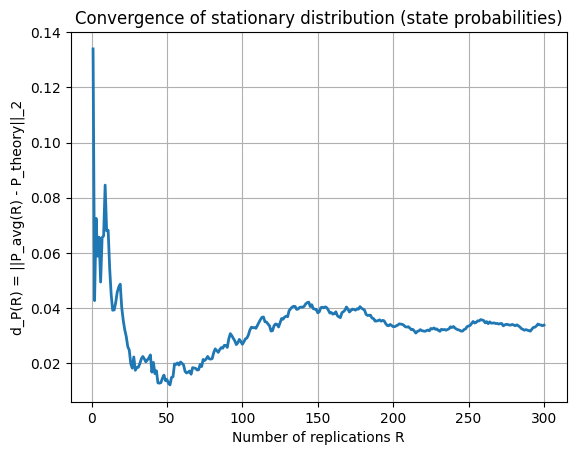

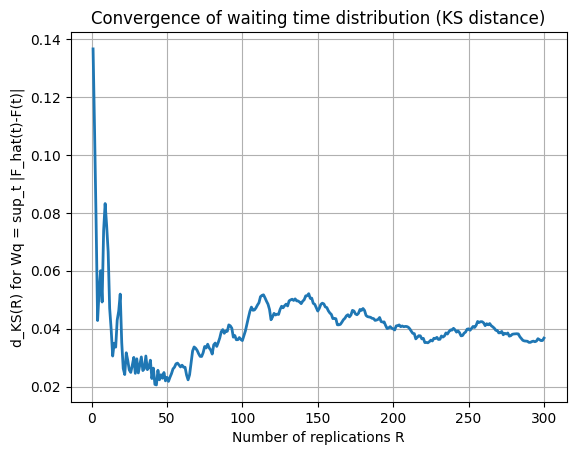

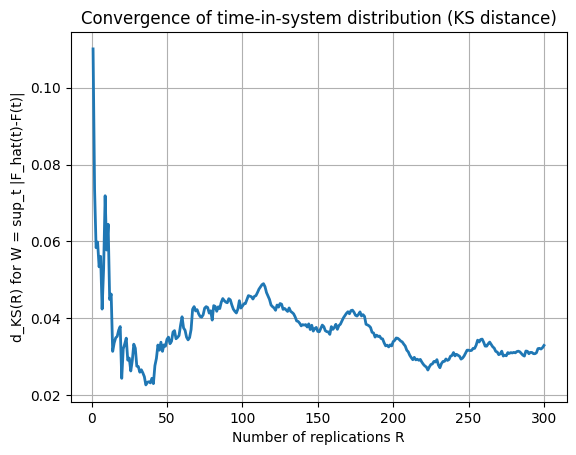

In [6]:

# У нас уже есть:
#   - аналитическое (теоретическое) решение для M/M/2/4 - В ВОРДЕ
#   - имитационная модель (симуляция), которая выдаёт выборочные оценки - ВЫШЕ
#
# Но симуляция ВСЕГДА даёт "шумный" результат: это случайная оценка.
# Поэтому надо:
#
# (3.1) ВВЕСТИ МЕТРИКУ совпадения "симуляция vs теория".
#       То есть определить функцию ошибки:
#           d = d(оценка_симуляции, значение_теории) >= 0
#       которая:
#         - равна 0 при идеальном совпадении,
#         - увеличивается, когда симуляция расходится с теорией,
#         - проверяет именно важные свойства (не только одно среднее).
#
# (3.2) ОЦЕНИТЬ СХОДИМОСТЬ:
#       построить ошибку как функцию количества итераций (обычно количества репликаций R):
#           R = 1,2,3,...  ->  d(R)
#       и показать, что при росте R ошибка убывает (обычно примерно как 1/sqrt(R)).
#
# КАКИЕ МЕТРИКИ МЫ ВЫБИРАЕМ:
#
# 1) Метрика по стационарному распределению состояний P=(P0,...,P4):
#       d_P(R) = || P_avg(R) - P_theory ||_2
#    где:
#       - P_theory — теоретические вероятности состояний,
#       - P_avg(R) — усреднение оценок P_hat по первым R репликациям,
#       - ||·||_2 — евклидова норма (L2).
#    Смысл:
#       Если P совпал, значит симуляция правильно воспроизводит доли времени, когда N(t)=n.
#       Это проверяет "сердце" марковского процесса N(t).
#
# 2) Метрика по распределениям: Kolmogorov/KS distance
#       d_KS(R) = sup_t | F_hat_R(t) - F_theory(t) |
#    где:
#       - F_theory(t) — теоретическая CDF распределения (например Wq),
#       - F_hat_R(t)  — эмпирическая CDF по всем наблюдениям из первых R репликаций,
#       - sup_t — максимум по t (на практике максимум по плотной сетке).
#    Смысл:
#       Мы сравниваем не только среднее время, а ПОЛНУЮ форму распределения (включая хвосты).
#
# ПОЧЕМУ ОЖИДАЕМ СХОДИМОСТЬ ~ 1/sqrt(R)
# ------------------------------------
# Для d_P(R):
#   P_avg(R) — среднее по независимым репликациям, значит по ЦПТ ошибка масштаба ~ 1/sqrt(R).
# Для d_KS(R):
#   Эмпирическая CDF сходится к теоретической (Glivenko–Cantelli / DKW),
#   типичный масштаб sup-ошибки ~ 1/sqrt(m), где m — число наблюдений.
#   А m растёт примерно линейно с числом репликаций R => снова примерно 1/sqrt(R).
#
import numpy as np
# - нам нужны массивы (np.array),
# - поэлементные операции (np.exp, np.abs),
# - сортировка и searchsorted для эмпирической CDF,
# - создание сеток (np.linspace),
# - sqrt, sum и т.п.

import matplotlib.pyplot as plt

# ============================================================
# BLOCK 0. ТЕОРИЯ: стационарные вероятности P_n

P_theory = np.array([1/9, 2/9, 2/9, 2/9, 2/9], dtype=float)
# Что это:
# - Это теоретический вектор P=(P0,P1,P2,P3,P4) из аналитического решения.
# Почему так:
# - В M/M/2/4 мы аналитически нашли P0=1/9 и P1=P2=P3=P4=2/9.
# Зачем нам это:
# - Метрика d_P(R) сравнивает симуляцию с теорией именно по P.
# Почему dtype=float:
# - чтобы вектор был вещественным; иначе могут появляться проблемы с типами при делениях/суммах.


# ============================================================
# BLOCK 1. ТЕОРИЯ: теоретические CDF распределений Wq и W

# Мы хотим сравнить распределения:
#   Wq = время ожидания в очереди
#   W  = время пребывания в системе (W = Wq + S, где S - сервис)
#
# Теория нужна, чтобы считать KS-метрику:
#   d_KS(R) = sup_t |F_emp(t) - F_theory(t)|

# 1.1 Теоретические вероятности состояния (для удобства отдельно)
P0 = 1/9
P1 = P2 = P3 = P4 = 2/9
# Почему мы снова задаём P0..P4:
# - чтобы формулы дальше читались проще (w0,w1,w2,w3).

# 1.2 Вероятность принятия (не отказа)
p_accept = 1.0 - P4
# Почему так:
# - отказ происходит только если система полна, т.е. N=4.
# - По PASTA для пуассоновских приходов вероятность "увидеть N=4 при приходе" = P4.
# - Значит вероятность принять = 1 - P4 = 7/9.

# 1.3 Условные вероятности состояний среди ПРИНЯТЫХ (важно!)
w0 = P0 / p_accept
w1 = P1 / p_accept
w2 = P2 / p_accept
w3 = P3 / p_accept
# Что это:
# - w0 = P(N=0 | accepted), и т.д.
# Почему делим на p_accept:
# - это обычная формула условной вероятности:
#     P(N=n | accepted) = P(N=n and accepted) / P(accepted)
# - а accepted означает N!=4, поэтому для n=0..3: P(N=n and accepted)=P(N=n).
# - значит просто нормируем (делим на 1-P4).

# 1.4 Масса в нуле для Wq
mass_zero = w0 + w1
# Почему:
# - если при приходе N=0 или N=1, хотя бы один бокс свободен -> ожидание в очереди Wq=0.
# - поэтому P(Wq=0 | accepted) = P(N=0|acc)+P(N=1|acc)=w0+w1.

# 1.5 Суммарная интенсивность завершений обслуживания, когда оба бокса заняты
rate_depart = 2.0 * MU
# Почему 2*MU:
# - если оба бокса заняты, то есть два независимых экспоненциальных "таймера" завершения.
# - завершение какого-то из двух произойдёт с интенсивностью μ+μ = 2μ.
# - для μ=1.5 получаем 3 завершения/час (в среднем раз в 20 минут).

# ---- Вспомогательные функции CDF ----

def cdf_exp(t, rate):
    """
    CDF экспоненциального распределения Exp(rate) для t>=0:
        F(t) = 1 - exp(-rate*t)
    """
    t = np.maximum(t, 0.0)
    # Почему np.maximum:
    # - теоретически CDF определена для t<0 как 0,
    # - если вдруг передадим отрицательное t, обрезаем в 0, чтобы не получить странные числа.

    return 1.0 - np.exp(-rate * t)
    # Почему np.exp:
    # - numpy считает exp поэлементно, если t - массив.
    # Это удобно, потому что мы часто подаём t как "сетку" (массив многих значений).

def cdf_erlang2(t, rate):
    """
    CDF Erlang(k=2, rate) для t>=0:
        F(t)=1-exp(-rate*t)*(1+rate*t)
    Erlang(2,rate) = Exp(rate) + Exp(rate) (сумма двух независимых).
    """
    t = np.maximum(t, 0.0)
    return 1.0 - np.exp(-rate * t) * (1.0 + rate * t)

def cdf_Wq_theory(t_hours):
    """
    Теоретическая CDF ожидания Wq | accepted.

    Логика смеси:
      - если пришли при N=0 или N=1 => Wq=0 (точечная масса) с вероятностью mass_zero
      - если пришли при N=2 => оба бокса заняты, но очередь 0:
            нужно дождаться 1 завершения обслуживания => Wq ~ Exp(2μ)
        вероятность этого случая = w2
      - если пришли при N=3 => оба бокса заняты, очередь 1:
            нужно дождаться 2 завершений => Wq ~ Erlang(2, 2μ)
        вероятность этого случая = w3

    Поэтому:
      F(t) = P(Wq<=t) = mass_zero + w2*F_exp(t;2μ) + w3*F_erlang2(t;2μ)
    """
    F = (
        mass_zero
        + w2 * cdf_exp(t_hours, rate_depart)
        + w3 * cdf_erlang2(t_hours, rate_depart)
    )
    return np.clip(F, 0.0, 1.0)
    # Почему clip:
    # - из-за численных ошибок может получиться 1.00000000002,
    # - clip принудительно держит значения CDF в [0,1].

# ---- Для W = Wq + S, где S~Exp(MU). Удобнее считать через survival: S(t)=P(X>t) ----

def surv_exp(t, rate):
    """
    Survival (tail) для Exp(rate):
        P(X > t) = exp(-rate*t)
    """
    t = np.maximum(t, 0.0)
    return np.exp(-rate * t)

def surv_hypoexp_2phase(t, r1, r2):
    """
    Survival для суммы Exp(r1) + Exp(r2), r1 != r2:
        P(X+Y > t) = (r2*e^{-r1 t} - r1*e^{-r2 t})/(r2 - r1)

    Почему это нужно:
    - При N=2: Wq~Exp(2μ), сервис S~Exp(μ)
      => W = Wq + S = Exp(2μ)+Exp(μ) (двухфазная гипоэкспонента).
    """
    t = np.maximum(t, 0.0)
    return (r2 * np.exp(-r1 * t) - r1 * np.exp(-r2 * t)) / (r2 - r1)

def surv_erlang2_plus_exp(t, a, b):
    """
    Survival для суммы:
        Y ~ Erlang(2, a)
        S ~ Exp(b)
        Z = Y + S

    Почему это нужно:
    - При N=3: Wq~Erlang(2,2μ), S~Exp(μ)
      => W = Erlang(2,2μ)+Exp(μ)

    Формула получена через условное ожидание:
      P(Y+S>t) = P(Y>t) + ∫_0^t P(S>t-y) f_Y(y) dy
    Здесь мы просто используем уже выведенную закрытую форму.
    """
    t = np.maximum(t, 0.0)
    c = a - b
    tailY = np.exp(-a * t) * (1.0 + a * t)
    integral = (1.0 / (c ** 2)) * (1.0 - np.exp(-c * t) * (1.0 + c * t))
    term = np.exp(-b * t) * (a ** 2) * integral
    return tailY + term

def cdf_W_theory(t_hours):
    """
    Теоретическая CDF времени в системе W | accepted.
    W = Wq + S, S~Exp(MU), и S независим от Wq.

    Смесь по состояниям:
      - N=0,1: Wq=0 => W=S~Exp(MU)        с вероятностью mass_zero
      - N=2:   W=Exp(2μ)+Exp(μ)           с вероятностью w2
      - N=3:   W=Erlang(2,2μ)+Exp(μ)      с вероятностью w3

    Считаем через survival:
      F_W(t) = 1 - P(W>t)
    """
    survival = (
        mass_zero * surv_exp(t_hours, MU)
        + w2 * surv_hypoexp_2phase(t_hours, rate_depart, MU)
        + w3 * surv_erlang2_plus_exp(t_hours, rate_depart, MU)
    )
    return np.clip(1.0 - survival, 0.0, 1.0)

# ============================================================
# BLOCK 2. ЭМПИРИЧЕСКАЯ CDF и KS-метрика

# Эмпирическая CDF — это "распределение по данным":
#   F_hat(t) = (кол-во наблюдений <= t) / (общее число наблюдений)
# KS-метрика берёт максимум разницы между F_hat и F_theory по t.

def empirical_cdf(samples, grid):
    """
    samples: массив наблюдений (например, все Wq из симуляции)
    grid: массив значений t, на которых вычисляем CDF

    Возвращаем массив F_hat(grid[i]) для каждого i.
    """
    samples = np.sort(samples)
    # Почему сортировка:
    # - чтобы быстро находить, сколько элементов <= t,
    # - searchsorted работает эффективно только на отсортированном массиве.

    return np.searchsorted(samples, grid, side="right") / samples.size
    # Почему searchsorted:
    # - searchsorted(samples, t, side="right") возвращает индекс вставки справа,
    #   т.е. количество элементов <= t.
    # - делим на samples.size -> получаем долю <= t, это и есть CDF.
    # Почему side="right":
    # - чтобы значения, равные t, тоже считались как <= t (стандарт для CDF).

def ks_distance(samples_hours, cdf_theory_func, grid_hours):
    """
    KS-дистанция на сетке:
      d_KS ≈ max_{t in grid} |F_hat(t) - F(t)|

    Почему на сетке:
    - теоретически нужно sup по всем t,
    - на практике берём плотную сетку и считаем максимум по ней.
    """
    F_emp = empirical_cdf(samples_hours, grid_hours)
    # строим эмпирическую CDF по данным симуляции

    F_th = cdf_theory_func(grid_hours)
    # строим теоретическую CDF на тех же точках

    return float(np.max(np.abs(F_emp - F_th)))
    # abs -> модуль разности в каждой точке
    # max -> максимальное расхождение (KS)
    # float(...) -> чтобы вернуть обычное число Python, удобное для печати/графика

# ============================================================
# BLOCK 3. Метрика по состояниям: L2-норма ||P_hat - P||


def l2_dist_P(P_hat):
    """
    Евклидова ошибка для вектора вероятностей:
      d_P = sqrt( Σ (P_hat[n] - P_theory[n])^2 )
    """
    diff = P_hat - P_theory
    # diff — вектор отклонений по каждому состоянию n.

    return float(np.sqrt(np.sum(diff ** 2)))
    # diff**2 — поэлементный квадрат
    # sum — сумма по n
    # sqrt — корень
    # получаем норму ||diff||_2

# ============================================================
# BLOCK 4. Главное: строим кривые сходимости d(R)

# Идея: у нас есть результаты по репликациям:
#   res_1, res_2, ..., res_Rmax
# Мы хотим после каждой новой репликации r иметь "текущую ошибку":
#   d_P(r), d_KS_Wq(r), d_KS_W(r)
#
# Почему это корректно:
# - репликации независимы, усреднение уменьшает дисперсию.
# - это соответствует требованию "ошибка как функция номера итерации".

def convergence_curves(results_list):
    """
    results_list: список словарей (по репликациям).
    Каждый res должен иметь ключи:
      - "P_hat"
      - "Wq_samples"
      - "W_samples"
    """
    dP = []
    dKS_Wq = []
    dKS_W = []
    # Эти списки будут хранить значения ошибок после r=1,2,... репликаций.

    P_cum = np.zeros_like(P_theory, dtype=float)
    # P_cum хранит сумму P_hat по всем уже добавленным репликациям.
    # Зачем: чтобы не пересчитывать сумму заново каждый раз.
    # Тогда P_avg = P_cum / r считаем O(1) на шаг.

    Wq_cum_parts = []
    W_cum_parts = []
    # Почему мы копим "кусками", а не сразу одним массивом:
    # - потому что на каждом шаге добавляется новый массив наблюдений,
    # - удобнее хранить как список и иногда concatenate.
    # Минус: concatenate на каждом шаге может быть дорогим при очень больших данных,
    # но для домашки нормально и прозрачно.

    grid_wq = np.linspace(0.0, 2.0, 800)
    grid_w = np.linspace(0.0, 3.0, 900)
    # Это сетки времени (в часах) для KS.
    # Почему 0..2 часа для Wq:
    # - ожидание редко будет больше 2 часов в такой системе; и нам хватает диапазона.
    # Почему много точек (800/900):
    # - чтобы хорошо аппроксимировать sup_t максимум по времени.

    for r, res in enumerate(results_list, start=1):
        # enumerate даёт пары (индекс, элемент).
        # start=1 значит первая репликация имеет номер r=1 (удобнее для графика).

        P_cum += res["P_hat"]
        # добавили оценку P из текущей репликации в кумулятивную сумму

        P_avg = P_cum / r
        # средний P по первым r репликациям
        # это и есть "экспериментальная оценка" P после r итераций

        dP.append(l2_dist_P(P_avg))
        # считаем ошибку по состояниям и добавляем в список

        if res["Wq_samples"].size > 0:
            Wq_cum_parts.append(res["Wq_samples"])
        # если в репликации есть данные Wq, добавляем их в накопление

        if res["W_samples"].size > 0:
            W_cum_parts.append(res["W_samples"])
        # аналогично для W

        Wq_all = np.concatenate(Wq_cum_parts) if len(Wq_cum_parts) > 0 else np.array([])
        W_all = np.concatenate(W_cum_parts) if len(W_cum_parts) > 0 else np.array([])
        # concatenate склеивает список массивов в один большой массив наблюдений
        # это выборка "все клиенты из первых r репликаций"

        if Wq_all.size > 0:
            dKS_Wq.append(ks_distance(Wq_all, cdf_Wq_theory, grid_wq))
        else:
            dKS_Wq.append(np.nan)
        # если выборка пустая, KS не определена => ставим NaN

        if W_all.size > 0:
            dKS_W.append(ks_distance(W_all, cdf_W_theory, grid_w))
        else:
            dKS_W.append(np.nan)

    return np.array(dP), np.array(dKS_Wq), np.array(dKS_W)
    # Возвращаем numpy-массивы, чтобы удобно строить графики.

# ============================================================
# BLOCK 5. Запуск: метрики -> графики

# Что покажут графики:
# 1) График d_P(R):
#    - по оси X: число репликаций R
#    - по оси Y: ошибка по стационарным вероятностям
#    Интерпретация:
#    - должна убывать к 0 при росте R (если симуляция корректна и репликации независимы)
#    - если "застыла" далеко от 0: значит либо симуляция неверна, либо теоретические P не те, либо R слишком мало.
#
# 2) График d_KS_Wq(R):
#    - по оси X: число репликаций R
#    - по оси Y: максимальная разница между эмпирической и теоретической CDF ожидания Wq
#    Интерпретация:
#    - падает к 0, когда распределение ожидания в симуляции приближается к теоретическому
#    - если хвосты шумные, падение может быть медленнее.
#
# 3) График d_KS_W(R):
#    - то же самое, но для времени пребывания в системе W.
#
# Ожидаемое поведение:
# - ошибки "шумят" при малых R, но тренд вниз должен быть.
# - типичный порядок убывания ~ 1/sqrt(R).
#   (Это можно объяснять ЦПТ и DKW.)


if __name__ == "__main__":
    out = run_many(R=300, base_seed=1)
    # run_many запускает твою симуляцию R раз.
    # out["results"] содержит список репликаций, каждая с P_hat, Wq_samples, W_samples.

    dP, dKS_Wq, dKS_W = convergence_curves(out["results"])
    # Считаем три кривые ошибки: одна по состояниям, две по распределениям.

    R_axis = np.arange(1, len(dP) + 1)
    # Формируем ось X: 1,2,...,Rmax
    # len(dP) = число репликаций

    plt.figure()
    plt.plot(R_axis, dP, linewidth=2)
    plt.xlabel("Number of replications R")
    plt.ylabel("d_P(R) = ||P_avg(R) - P_theory||_2")
    plt.title("Convergence of stationary distribution (state probabilities)")
    plt.grid(True)
    # Этот график показывает: насколько быстро симуляция приближается к теоретическому P.

    plt.figure()
    plt.plot(R_axis, dKS_Wq, linewidth=2)
    plt.xlabel("Number of replications R")
    plt.ylabel("d_KS(R) for Wq = sup_t |F_hat(t)-F(t)|")
    plt.title("Convergence of waiting time distribution (KS distance)")
    plt.grid(True)
    # Этот график показывает: насколько совпадает распределение ожидания Wq (пункт 9).

    plt.figure()
    plt.plot(R_axis, dKS_W, linewidth=2)
    plt.xlabel("Number of replications R")
    plt.ylabel("d_KS(R) for W = sup_t |F_hat(t)-F(t)|")
    plt.title("Convergence of time-in-system distribution (KS distance)")
    plt.grid(True)
    # Этот график показывает: насколько совпадает распределение времени в системе W (пункт 10).

    plt.show()
    # Показываем все графики.

Теор. обзор итого:

In [ ]:
"""
===========================================
ТЕОРЕТИЧЕСКИЙ БЛОК
===========================================

1) 2, 3

(1) Аналитика уже сделана:
    Мы вывели точные характеристики СМО в рамках допущений "все потоки простейшие":
    - приходы: пуассоновский поток с интенсивностью λ (межприходы ~ Exp(λ))
    - обслуживание: экспоненциальное с интенсивностью μ (время сервиса ~ Exp(μ))
    - c=2 параллельных сервера (2 бокса)
    - вместимость системы K=4 (максимум 4 заявки внутри: 2 в сервисе + 2 в очереди)
    Модель: M/M/2/4.

(2) Имитационная модель (Simulation / Discrete-Event):
    Нужно программно "проиграть" жизнь системы во времени:
    - генерировать случайные приходы,
    - обслуживать заявки на 2 серверах,
    - держать очередь,
    - отказывать, если система заполнена (N=4),
    - собирать метрики (средние, вероятности, распределения).
    Это нужно потому что:
    - в реальных системах часто нет аналитического решения (неэкспоненциальные времена, приоритеты, расписания, λ(t), сложные правила).
    - симуляция даёт приближённый ответ со статистической ошибкой, и важно уметь этой ошибкой управлять.

(3) Метрика совпадения + скорость сходимости:
    Нужно формально определить численную "ошибку" между:
      теоретическим (аналитическим) решением и экспериментальным (симуляционным),
    и показать, как эта ошибка убывает при увеличении числа прогонов/наблюдений.

----------------------------------------------------------------------
2) МОДЕЛЬ И ОБОЗНАЧЕНИЯ: M/M/2/4

Параметры из условия:
    λ = 3  [1/час]        (в среднем 3 машины в час)
    E[S] = 40 минут = 2/3 часа
    μ = 1/E[S] = 1.5 [1/час]   (интенсивность обслуживания 1 бокса)
    c = 2  (два бокса)
    K = 4  (максимум машин в системе: 2 сервис + 2 ожидание)
    горизонт моделирования: T = 12 часов

Состояние системы:
    N(t) = число машин в системе (в очереди + в обслуживании), N(t) ∈ {0,1,2,3,4}
    S(t) = число занятых боксов = min(N(t), c)
    Q(t) = длина очереди = max(N(t) - c, 0)

В стационарности интересуют:
    P_n = P(N(t)=n)  (при t→∞), эквивалентно доля времени, когда система в состоянии n.

Для данной задачи (аналитика):
    P0 = 1/9
    P1 = P2 = P3 = P4 = 2/9

Эффективный поток принятых заявок:
    λ_eff = λ * (1 - P_block)
где
    P_block = P4 (по PASTA для пуассоновских приходов).

----------------------------------------------------------------------
3) КАКИЕ ВЫХОДЫ НУЖНО СОБИРАТЬ В СИМУЛЯЦИИ

Есть два типа усреднений — их важно различать.

(A) Time-average (временные средние):
    Эти величины считаются через интеграл по времени, потому что
    между событиями состояние постоянно.

    Оценка стационарных вероятностей:
        P̂_n(T) = (1/T) ∫_0^T 1{N(t)=n} dt

    Среднее число в системе:
        L̂(T) = (1/T) ∫_0^T N(t) dt

    Среднее число в очереди:
        L̂_q(T) = (1/T) ∫_0^T Q(t) dt

    В дискретно-событийной симуляции интегралы считаются так:
        если на интервале (t_prev, t_now) состояние было N = const,
        то вклад в ∫ N(t) dt равен N * (t_now - t_prev).

(B) Customer-average (по заявкам):
    Берём только принятые заявки i=1..M и считаем по ним времена:

    Время ожидания в очереди:
        Wq_i = (момент начала обслуживания) - (момент прихода)

    Время пребывания в системе:
        W_i = (момент ухода) - (момент прихода) = Wq_i + S_i

    Тогда оценки:
        Ŵ_q = (1/M) Σ Wq_i
        Ŵ   = (1/M) Σ W_i

Также интересны вероятности:
    P̂_block = blocked / total_arrivals
    P̂_immediate = immediate / accepted
где immediate — число принятых заявок с Wq=0.

----------------------------------------------------------------------
4) ПОЧЕМУ РАБОТАЕТ ЗАКОН ЛИТТЛА (Little's Law)

Для устойчивой стационарной системы:

    L = λ_eff * W
    Lq = λ_eff * Wq

Смысл:
    Суммарное "машино-время" внутри системы можно посчитать двумя способами:
    - суммируя времена пребывания по заявкам: Σ W_i
    - интегрируя число машин по времени: ∫ N(t) dt
    При делении на T получаем равенство средних.

Размерности:
    (заявок/час) * (час) = заявок
поэтому "поток × время" даёт "среднее число внутри".

----------------------------------------------------------------------
5) МЕТРИКА СОВПАДЕНИЯ (ТВОРЧЕСКАЯ КОМПОНЕНТА) И СХОДИМОСТЬ

Нужно не просто "похоже/не похоже", а определить:
    d(simulation, theory) ≥ 0

Вариант 1 (метрика по состояниям):
    сравниваем стационарные вероятности:

    d_P(R) = || P̄_R - P ||_2
           = sqrt( Σ_{n=0}^4 (P̄_{n,R} - P_n)^2 )

где P̄_R — среднее по R независимым репликациям.

Обоснование:
    P описывает стационарное поведение процесса N(t).
    Если P совпадает, то функционалы от P (L, Lq и др.) тоже близки.

Сходимость:
    По ЦПТ для независимых репликаций:
        P̄_R - P = O_p(1/sqrt(R))
    значит ожидаемая ошибка d_P(R) убывает примерно как 1/sqrt(R).

Вариант 2 (метрика по распределениям, супер-сильная):
    сравниваем эмпирическую CDF ожиданий/пребываний с теоретической.

    d_KS(R) = sup_t | F̂_R(t) - F(t) |
    (Kolmogorov/KS distance)

Обоснование:
    Это напрямую проверяет пункты 9 и 10 (законы распределения Wq и W),
    чувствительно к хвостам (важно для SLA).

Сходимость:
    По теории эмпирических распределений (Glivenko–Cantelli / DKW):
        sup_t |F̂(t)-F(t)| = O_p(1/sqrt(m))
    где m — число наблюдений (принятых клиентов),
    а m обычно растёт примерно линейно с числом репликаций R,
    значит типично d_KS(R) ~ O(1/sqrt(R)).

----------------------------------------------------------------------
6) ЧТО ДОЛЖНО БЫТЬ НА ГРАФИКАХ СХОДИМОСТИ

Строим:
    R -> d_P(R)
    R -> d_KS_Wq(R)
    R -> d_KS_W(R)

Ожидаем:
    - убывание ошибок при росте R,
    - возможные "колебания" при малых R (из-за дисперсии),
    - приблизительное поведение ~ 1/sqrt(R).
    Для наглядности можно строить log-log график и оценить наклон ≈ -0.5.

----------------------------------------------------------------------
7) ВАЖНЫЕ ПРАКТИЧЕСКИЕ МОМЕНТЫ (чтобы всё сошлось)

- Для time-average метрик нужно корректно интегрировать по времени между событиями.
- Для оценки сходимости удобнее делать много независимых репликаций (R=200..500),
  чем один очень длинный прогон (где мешает автокорреляция).
- Важно фиксировать seed или base_seed, чтобы результаты были воспроизводимы.
- Для метрик по распределениям нужно достаточно наблюдений (много принятых клиентов),
  иначе хвосты CDF будут шумными.

